In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [27]:
# --- Algol / eclipsing binary: load AAVSO-style CSV ---
csv_path = "algol.csv"  # same folder as notebook, or use full path

df = pd.read_csv(csv_path)

# Expect columns: RHJD, V, eV (adjust names if your export differs)
t = df["RHJD"].to_numpy(dtype=float)
V = df["V"].to_numpy(dtype=float)
eV = df["eV"].to_numpy(dtype=float)

# Basic cleaning
mask = np.isfinite(t) & np.isfinite(V) & np.isfinite(eV)
mask &= (eV > 0) & (eV < 5)  # drop bogus AAVSO error sentinels
mask &= (V > 0) & (V < 25)

t, V, eV = t[mask], V[mask], eV[mask]
print(f"N points after clean: {len(t)}")

# Magnitude -> linear flux (arbitrary scale; we normalize next)
flux = 10 ** (-0.4 * V)

# Rough out-of-eclipse mask: exclude faintest ~15% of points (often in eclipse)
cut = np.quantile(flux, 0.15)
in_eclipse_guess = flux <= cut
baseline_flux = np.median(flux[~in_eclipse_guess])
flux_norm = flux / baseline_flux

# Uncertainty propagation: sigma_f ~ 0.4 ln(10) * f * sigma_V (flux scale before norm)
sig_flux_raw = (0.4 * np.log(10)) * flux * eV
sig_flux = sig_flux_raw / baseline_flux

print(f"Flux normalized: median baseline ~ {np.median(flux_norm[~in_eclipse_guess]):.4f}")

N points after clean: 229
Flux normalized: median baseline ~ 1.0000


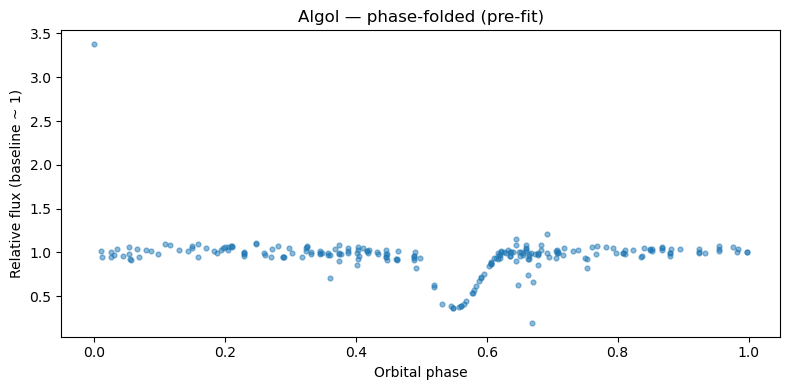

In [28]:
# Orbital period (days) — cite literature; ~2.8673 d for Algol
P = 2.8673

# Reference epoch: time of deepest point in this dataset (good enough for class work)
t0 = float(t[np.argmin(V)])

phi = np.mod((t - t0) / P, 1.0)

# Optional: show folded light curve before fitting
plt.figure(figsize=(8, 4))
plt.scatter(phi, flux_norm, s=12, alpha=0.5)
plt.xlabel("Orbital phase")
plt.ylabel("Relative flux (baseline ~ 1)")
plt.title("Algol — phase-folded (pre-fit)")
plt.tight_layout()
plt.show()

In [29]:
def phase_circ_diff(phi, c):
    """Wrapped difference on [0, 1) so Gaussians work near phase 0."""
    return (phi - c + 0.5) % 1.0 - 0.5


def two_gauss_eclipse(phi, F0, d1, w1, c1, d2, w2, c2):
    """
    phi in [0, 1). Two Gaussian dips in phase space.
    w = sigma in phase units (not FWHM).
    """
    w1 = max(float(w1), 1e-8)
    w2 = max(float(w2), 1e-8)
    z1 = phase_circ_diff(phi, c1) / w1
    z2 = phase_circ_diff(phi, c2) / w2
    g1 = np.exp(-0.5 * z1**2)
    g2 = np.exp(-0.5 * z2**2)
    return F0 - d1 * g1 - d2 * g2


def initial_guesses(phi, y):
    F0 = float(np.median(y))
    resid = F0 - y
    d_guess = float(np.clip(np.max(resid), 0.02, 0.95))
    c1, c2 = 0.0, 0.5
    w1 = w2 = 0.02
    return F0, d_guess, w1, c1, 0.5 * d_guess, w2, c2


p0 = initial_guesses(phi, flux_norm)

# F0, d1, w1, c1, d2, w2, c2
lower = [0.5, 0.0, 1e-4, -0.2, 0.0, 1e-4, 0.15]
upper = [1.5, 1.5, 0.25, 0.2, 1.5, 0.25, 0.85]

popt, pcov = curve_fit(
    two_gauss_eclipse,
    phi,
    flux_norm,
    p0=p0,
    bounds=(lower, upper),
    sigma=sig_flux,
    absolute_sigma=True,
    maxfev=500000,
)

diag = np.diag(pcov)
perr = np.sqrt(np.where(diag > 0, diag, np.nan))
names = ["F0", "d1", "w1", "c1", "d2", "w2", "c2"]
print("Fitted parameters:")
for n, v, e in zip(names, popt, perr):
    es = f"{e:.5f}" if np.isfinite(e) else "nan (poorly constrained)"
    print(f"  {n} = {v:.5f} +/- {es}")

phi_dense = np.linspace(0, 1, 4000)
model_dense = two_gauss_eclipse(phi_dense, *popt)
model_at_pts = two_gauss_eclipse(phi, *popt)
resid = flux_norm - model_at_pts


Fitted parameters:
  F0 = 0.99174 +/- 0.00007
  d1 = 0.03695 +/- 18374.71490
  w1 = 0.00115 +/- 26.21485
  c1 = 0.00540 +/- 2.94086
  d2 = 0.64359 +/- 0.00026
  w2 = 0.02985 +/- 0.00001
  c2 = 0.55172 +/- 0.00001


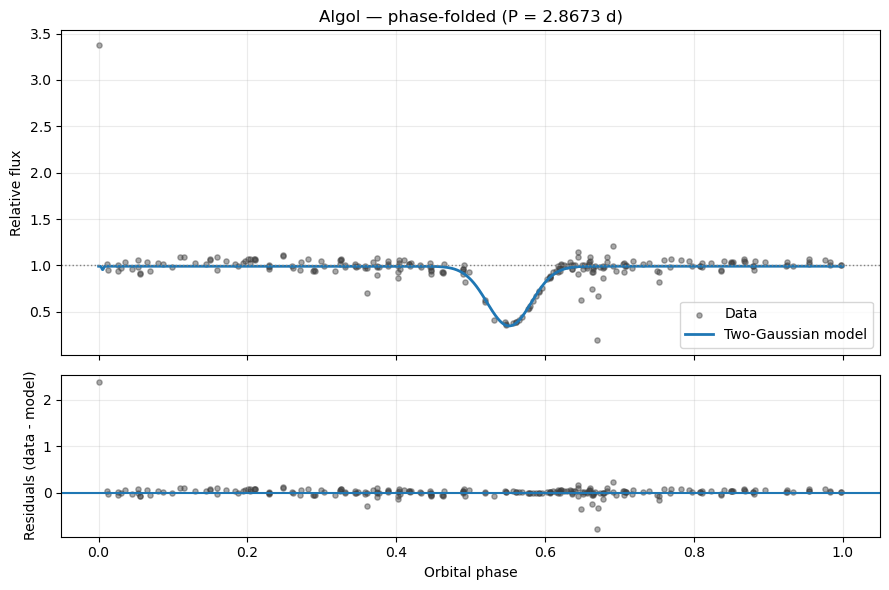

Residual RMS (all points): 0.1776


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.scatter(phi, flux_norm, s=14, alpha=0.45, color="0.25", label="Data")
ax.plot(phi_dense, model_dense, color="C0", lw=2, label="Two-Gaussian model")
ax.axhline(1.0, color="0.5", ls=":", lw=1)
ax.set_ylabel("Relative flux")
ax.set_title(f"Algol — phase-folded (P = {P} d)")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

ax2 = axes[1]
ax2.scatter(phi, resid, s=14, alpha=0.45, color="0.25")
ax2.axhline(0, color="C0", lw=1.5)
ax2.set_xlabel("Orbital phase")
ax2.set_ylabel("Residuals (data - model)")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

rms = float(np.std(resid))
print(f"Residual RMS (all points): {rms:.4f}")
